## **Approach # 2** : **Transfer Learning / Fine-Tuning ko live**

* **niche/specialized task** (taake pre-trained model direct kaam na kare, aur custom training lazmi lage).



### Custom Word Activator using Transfer Learning

Hum ek pre-trained deep learning model uthayenge aur usay fine-tune karenge do custom words par (e.g., "Go" vs "Stop").

> Hum Hugging Face se Facebook ka Wav2Vec2 ya Google ka Audio Spectrogram Transformer (AST) base model uthayenge. Is model ko aawaz ki samajh pehle se hai, hum bas uski aakhri layer ko apne custom data par 3 epochs ke liye fine-tune karenge.



#### Step 1: Dependecy & Setup

In [ ]:
import os
import torch
import torchaudio
from transformers import AutoFeatureExtractor, AutoModelForAudioClassification, TrainingArguments, Trainer
from datasets import Dataset

# 1. Base model aur extractor badal kar Meta ka Wav2Vec2 rakh rahe hain (Yeh bilkul open hai)
model_id = "facebook/wav2vec2-base"
feature_extractor = AutoFeatureExtractor.from_pretrained(model_id)

# 2. Dataset download karein
os.makedirs("./speech_data", exist_ok=True)
base_dataset = torchaudio.datasets.SPEECHCOMMANDS(root="./speech_data", download=True)

print("Step 1 successfully complete! Model and dataset loaded.")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/159 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.84k [00:00<?, ?B/s]

100%|██████████| 2.26G/2.26G [00:31<00:00, 76.1MB/s]


Step 1 successfully complete! Model and dataset loaded.


### Step 2: Fine Tune Dataset
Google/Google Brain ka yeh Speech Commands Dataset asal mein un logon ke liye banaya gaya hai jo voice assistants (jaise Google Assistant ya Alexa) par kaam karte hain.

Is mein kya hai: Is dataset mein total 35 mukhtalif chote words (commands) hain. Har word ko hazaron mukhtalif logon ne record kiya hai taake har tarah ki voice aur accent cover ho sake.

Kaunse words hain: Is mein directional commands hain (up, down, left, right), action commands hain (go, stop, on, off, yes, no), aur numbers hain (one, two, three...).

Audio Quality: Har file bilkul 1 second ki hai aur 16,000Hz (16kHz) sample rate par record ki gayi hai, jo ke speech recognition ke liye standard hai.

In [ ]:
import random

def create_subset_fast(base_ds):
    data_dict = {"audio": [], "label": []}
    counts = {"go": 0, "stop": 0}

    # Dataset ke saare indices ka ek random sequence bana lete hain
    indices = list(range(len(base_ds)))
    random.seed(42)
    random.shuffle(indices)

    print("Scanning dataset randomly for 'go' and 'stop' samples...")

    for i in indices:
        waveform, sample_rate, label, _, _ = base_ds[i]

        if label in counts and counts[label] < 30:
            audio_data = waveform.squeeze().numpy()

            # Wav2Vec2 Feature Extractor
            inputs = feature_extractor(audio_data, sampling_rate=16000, return_tensors="np")

            data_dict["audio"].append(inputs["input_values"][0])
            data_dict["label"].append(0 if label == "go" else 1)
            counts[label] += 1

        if counts["go"] == 30 and counts["stop"] == 30:
            break

    return Dataset.from_dict(data_dict)

# Naya fast subset banayein
hf_dataset = create_subset_fast(base_dataset)
hf_dataset = hf_dataset.train_test_split(test_size=0.2, seed=42)
print("🔥 Subset ready for Transfer Learning instantly!")

Scanning dataset randomly for 'go' and 'stop' samples...
🔥 Subset ready for Transfer Learning instantly!


In [ ]:
import IPython.display as ipd

# Dataset se koi bhi ek sample index uthayein (e.g., sample number 10)
waveform, sample_rate, label, speaker_id, utterance_number = base_dataset[1978]

print(f"Bole jane wala lafz (Label): {label}")
print(f"Sampling Rate: {sample_rate} Hz")

# Browser mein audio player show karne ke liye
ipd.Audio(waveform.numpy(), rate=sample_rate)

Bole jane wala lafz (Label): bed
Sampling Rate: 16000 Hz


##

### Step 3 Model Configuration (Approach 2 - Transfer Learning)

In [ ]:
# Nayi blank layer lagane ke liye num_labels=2 set karein
model = AutoModelForAudioClassification.from_pretrained(
    model_id,
    num_labels=2,
    ignore_mismatched_sizes=True
)

pytorch_model.bin:   0%|          | 0.00/380M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/380M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

[transformers] Wav2Vec2ForSequenceClassification LOAD REPORT from: facebook/wav2vec2-base
Key                          | Status     | 
-----------------------------+------------+-
project_hid.bias             | UNEXPECTED | 
quantizer.weight_proj.bias   | UNEXPECTED | 
project_q.weight             | UNEXPECTED | 
quantizer.codevectors        | UNEXPECTED | 
quantizer.weight_proj.weight | UNEXPECTED | 
project_hid.weight           | UNEXPECTED | 
project_q.bias               | UNEXPECTED | 
classifier.bias              | MISSING    | 
projector.bias               | MISSING    | 
projector.weight             | MISSING    | 
classifier.weight            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
import random

def create_subset_fast_fixed(base_ds):
    data_dict = {"input_values": [], "label": []}  # Key ka naam 'audio' se badal kar 'input_values' kar diya
    counts = {"go": 0, "stop": 0}

    indices = list(range(len(base_ds)))
    random.seed(42)
    random.shuffle(indices)

    print("Scanning dataset randomly for 'go' and 'stop' samples...")

    for i in indices:
        waveform, sample_rate, label, _, _ = base_ds[i]

        if label in counts and counts[label] < 30:
            audio_data = waveform.squeeze().numpy()

            # Feature extractor se tensors extract karein aur padding right set karein
            inputs = feature_extractor(audio_data, sampling_rate=16000, return_tensors="np")

            # input_values ko list format mein save karein
            data_dict["input_values"].append(inputs["input_values"][0].tolist())
            data_dict["label"].append(0 if label == "go" else 1)
            counts[label] += 1

        if counts["go"] == 30 and counts["stop"] == 30:
            break

    return Dataset.from_dict(data_dict)

# Dataset dobara banayein sahi keys ke sath
hf_dataset = create_subset_fast_fixed(base_dataset)
hf_dataset = hf_dataset.train_test_split(test_size=0.2, seed=42)
print("🔥 Subset re-engineered with 'input_values' key successfully!")

Scanning dataset randomly for 'go' and 'stop' samples...
🔥 Subset re-engineered with 'input_values' key successfully!


## 4 Training moodel

In [ ]:
from transformers import TrainingArguments, Trainer, DataCollatorWithPadding

# 1. Training parameters set karein
training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",            # Har epoch ke baad validation check hogi
    learning_rate=3e-5,               # Fine-tuning ke liye optimize learning rate
    per_device_train_batch_size=8,
    num_train_epochs=3,               # Live demo ke liye sirf 3 epochs
    weight_decay=0.01,
    logging_steps=5,
    remove_unused_columns=False
)

# 2. Data Collator (Ab yeh input_values ko detect kar lega)
data_collator = DataCollatorWithPadding(tokenizer=feature_extractor)

# 3. Trainer initialize karein
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=hf_dataset["train"],
    eval_dataset=hf_dataset["test"],
    data_collator=data_collator
)

# 4. Fine-tuning shuru karein
print("🚀 Fine-tuning shuru ho rahi hai...")
trainer.train()

🚀 Fine-tuning shuru ho rahi hai...


Epoch,Training Loss,Validation Loss
1,0.705165,0.692547
2,0.670215,0.679193
3,0.635668,0.655105


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


TrainOutput(global_step=18, training_loss=0.6694323751661513, metrics={'train_runtime': 200.9074, 'train_samples_per_second': 0.717, 'train_steps_per_second': 0.09, 'total_flos': 1307323100160000.0, 'train_loss': 0.6694323751661513, 'epoch': 3.0})

## Final Step : Live Inference (Ab Model Test Karte Hain!)

In [ ]:
import torch
import numpy as np

# 1. Test set se pehla sample uthayein
test_sample = hf_dataset["test"][0]

# 2. Input values ko torch tensor mein badal kar batch dimension [1, time_steps] add karein
input_tensor = torch.tensor([test_sample["input_values"]])

# 3. Model ko evaluation mode mein dalen aur predict karein
model.eval()
with torch.no_grad():
    logits = model(input_tensor).logits
    predicted_class_id = torch.argmax(logits, dim=-1).item()

# 4. Labels mapping
labels_map = {0: "Go", 1: "Stop"}
true_label = labels_map[test_sample["label"]]
predicted_label = labels_map[predicted_class_id]

print(f"🎯 Asal Word (True Label): {true_label}")
print(f"🤖 Model ki Prediction: {predicted_label}")

🎯 Asal Word (True Label): Go
🤖 Model ki Prediction: Go


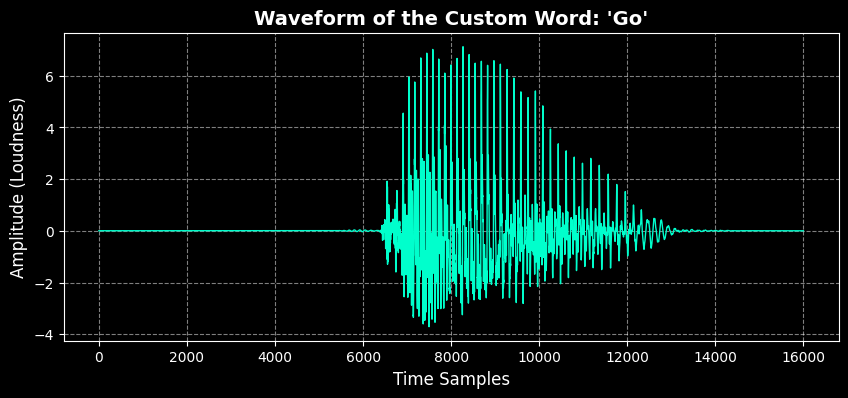

In [ ]:
import matplotlib.pyplot as plt

# 1. Test sample se audio signal (input_values) uthayein
audio_signal = hf_dataset["test"][0]["input_values"]
word_label = "Go" if hf_dataset["test"][0]["label"] == 0 else "Stop"

# 2. Iska graph (Waveform) plot karein
plt.figure(figsize=(10, 4))
plt.plot(audio_signal, color="#00ffcc", linewidth=1)
plt.title(f"Waveform of the Custom Word: '{word_label}'", fontsize=14, fontweight='bold')
plt.xlabel("Time Samples", fontsize=12)
plt.ylabel("Amplitude (Loudness)", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.5)
plt.style.use('dark_background') # Poster/Workshop theme jesa cool look dene ke liye
plt.show()

In [ ]:
import IPython.display as ipd
import numpy as np

# 1. Test sample se audio values (list) uthayein aur numpy array banayein
audio_data = np.array(hf_dataset["test"][0]["input_values"])

# 2. Label check karein kya tha
word_label = "Go" if hf_dataset["test"][0]["label"] == 0 else "Stop"
print(f"🔈 Listening to the test audio clip for: '{word_label}'")

# 3. Audio Player display karein (Wav2Vec2 ka standard rate 16000Hz hai)
ipd.Audio(audio_data, rate=16000)

🔈 Listening to the test audio clip for: 'Go'
